In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import expon, pareto

## System Parameters

| Symbol | Meaning |
|---|---|
| $N$ | Number of agents |
| $M$ | Total cash in the system |
| $S_{\text{total}}$ | Total shares in the system |
| $p_0$ | Initial stock price |
| $\lambda$ | Price-impact coefficient |
| $\text{steps}$ | Number of simulation time steps |

In [2]:
# --- System parameters ---
N          = 500        # number of agents
M          = 5e5        # total cash
S_total    = 5000       # total shares in the system
p0         = 100.0      # initial stock price
lam        = 0.01       # price-impact coefficient
steps      = int(4e5)   # number of simulation steps

# Derived
T0 = M / N              # initial "temperature" (mean cash per agent)
print(f"Agents: {N},  Total cash: {M:.0f},  Total shares: {S_total}")
print(f"Initial price: {p0},  Mean cash/agent: {T0:.1f},  Mean shares/agent: {S_total/N:.1f}")

Agents: 500,  Total cash: 500000,  Total shares: 5000
Initial price: 100.0,  Mean cash/agent: 1000.0,  Mean shares/agent: 10.0


## Simulation

### Transaction types

At each time step, a random transaction type is chosen:

1. **Cash trade** (probability $q_c$): Agent $i$ gives $\Delta m$ cash to agent $j$.  
   $m_i' = m_i - \Delta m, \quad m_j' = m_j + \Delta m$

2. **Stock trade** (probability $q_s$): Agent $i$ buys $\Delta s$ shares from agent $j$ at price $p$.  
   $m_i' = m_i - p\,\Delta s, \quad s_i' = s_i + \Delta s$  
   $m_j' = m_j + p\,\Delta s, \quad s_j' = s_j - \Delta s$

### Price update

After each stock trade the price reacts to net demand:

$$p \leftarrow p \cdot \exp\!\bigl(\lambda \cdot \text{sign}(\text{buyer} - \text{seller})\bigr)$$

### Constraints

- $m_i \geq 0$ (no debt)
- $s_i \geq 0$ (no short selling)
- Buyer must have enough cash; seller must own enough shares

In [3]:
def simulate_stock_market(N=500, M=5e5, S_total=5000, p0=100.0,
                          lam=0.01, steps=int(4e5), q_stock=0.5,
                          record_every=1000):
    """
    Stock-market extension of the Boltzmann-Gibbs money model.

    Parameters
    ----------
    N         : number of agents
    M         : total cash in the system
    S_total   : total shares in the system
    p0        : initial stock price
    lam       : price-impact coefficient
    steps     : number of transaction steps
    q_stock   : probability that a given step is a stock trade (vs cash trade)
    record_every : how often to snapshot price and mean wealth

    Returns
    -------
    cash      : (N,) final cash distribution
    shares    : (N,) final shares distribution
    price     : scalar, final price
    price_history  : list of (step, price) snapshots
    wealth_history : list of (step, mean_wealth) snapshots
    """
    # --- Initialisation ---
    cash   = np.ones(N) * M / N                   # equal cash
    shares = np.ones(N) * S_total / N             # equal shares
    p      = float(p0)

    price_history  = [(0, p)]
    wealth_history = [(0, np.mean(cash + p * shares))]

    rng = np.random.default_rng()

    for t in range(1, steps + 1):
        # Pick two distinct agents
        i, j = rng.choice(N, 2, replace=False)

        if rng.random() > q_stock:
            # ── Cash trade (fraction of system average) ──────────────────
            delta = rng.random() * np.mean(cash)
            if cash[i] >= delta:
                cash[i] -= delta
                cash[j] += delta

        else:
            # ── Stock trade ───────────────────────────────────────────────
            # i tries to buy from j; skip if j has no shares
            if shares[j] < 1:
                continue
            # Buy 1 share (integer shares for simplicity)
            cost = p * 1.0
            if cash[i] >= cost:
                cash[i]   -= cost
                cash[j]   += cost
                shares[i] += 1.0
                shares[j] -= 1.0
                # Price impact: demand met → price rises slightly
                p *= np.exp(lam)
            else:
                # i wants to sell instead: i sells 1 share to j
                if shares[i] < 1:
                    continue
                if cash[j] >= cost:
                    cash[j]   -= cost
                    cash[i]   += cost
                    shares[j] += 1.0
                    shares[i] -= 1.0
                    # Supply > demand → price falls slightly
                    p *= np.exp(-lam)

        if t % record_every == 0:
            price_history.append((t, p))
            wealth_history.append((t, np.mean(cash + p * shares)))

    return cash, shares, p, price_history, wealth_history

## Run the Simulation

In [4]:
cash, shares, p_final, price_hist, wealth_hist = simulate_stock_market(
    N=N, M=M, S_total=S_total, p0=p0, lam=lam, steps=steps, q_stock=0.5
)

wealth = cash + p_final * shares

print(f"Final price       : {p_final:.4f}")
print(f"Cash conserved    : {cash.sum():.2f}  (expected {M:.2f})")
print(f"Shares conserved  : {shares.sum():.1f}  (expected {S_total})")
print(f"Mean wealth       : {wealth.mean():.2f}")
print(f"Std  wealth       : {wealth.std():.2f}")
print(f"Gini coefficient  : {(np.sum(np.abs(np.subtract.outer(wealth, wealth))) / (2 * N * wealth.sum())):.4f}")

Final price       : 6602.2791
Cash conserved    : 500000.00  (expected 500000.00)
Shares conserved  : 5000.0  (expected 5000)
Mean wealth       : 67022.79
Std  wealth       : 9119.05
Gini coefficient  : 0.0759


## Wealth Distribution and Boltzmann-Gibbs Comparison

We plot $P(w)$ and fit both an **exponential** (BG) and a **Pareto** tail to check which describes the stationary distribution better.

- BG:  $P(w) = \frac{1}{T}\exp(-w/T)$, with $T = \langle w \rangle$  
- Pareto tail expected if price fluctuations break strict conservation of wealth

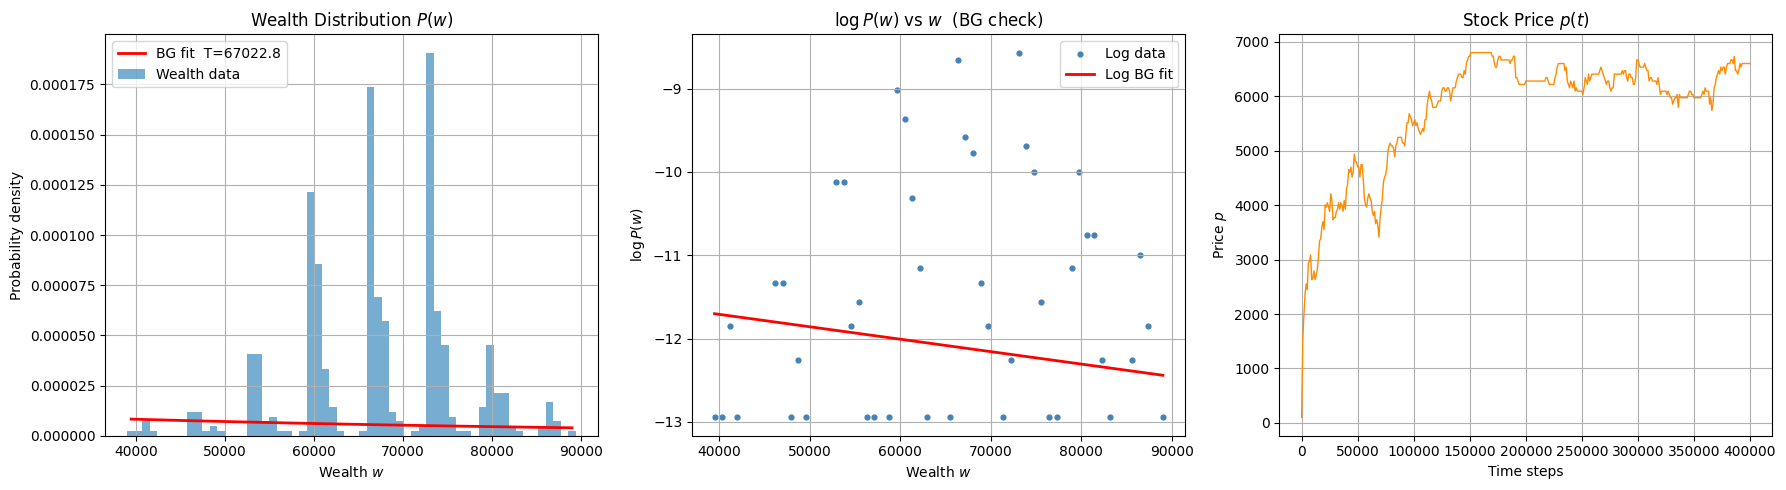

In [5]:
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# ── (1) Wealth distribution with BG fit ─────────────────────────────────────
w_hist, w_bins = np.histogram(wealth, bins=60, density=True)
w_centers = 0.5 * (w_bins[1:] + w_bins[:-1])

T_w = np.mean(wealth)
bg_fit = (1 / T_w) * np.exp(-w_centers / T_w)

axs[0].bar(w_centers, w_hist, width=np.diff(w_bins), alpha=0.6, label='Wealth data')
axs[0].plot(w_centers, bg_fit, 'r-', lw=2, label=f'BG fit  T={T_w:.1f}')
axs[0].set_title("Wealth Distribution $P(w)$")
axs[0].set_xlabel("Wealth $w$")
axs[0].set_ylabel("Probability density")
axs[0].legend()
axs[0].grid(True)

# ── (2) Log-linear plot to check exponential tail ───────────────────────────
mask = w_hist > 0
axs[1].scatter(w_centers[mask], np.log(w_hist[mask]), s=12, color='steelblue', label='Log data')
axs[1].plot(w_centers, np.log(bg_fit), 'r-', lw=2, label='Log BG fit')
axs[1].set_title("$\\log P(w)$ vs $w$  (BG check)")
axs[1].set_xlabel("Wealth $w$")
axs[1].set_ylabel("$\\log P(w)$")
axs[1].legend()
axs[1].grid(True)

# ── (3) Price time series ────────────────────────────────────────────────────
steps_arr, prices = zip(*price_hist)
axs[2].plot(steps_arr, prices, color='darkorange', lw=1)
axs[2].set_title("Stock Price $p(t)$")
axs[2].set_xlabel("Time steps")
axs[2].set_ylabel("Price $p$")
axs[2].grid(True)

plt.tight_layout()
plt.show()

## Separate Cash and Shares Distributions

We look at $P(m)$ and $P(s)$ independently to see whether the cash component alone still follows BG, and how shares spread among agents.

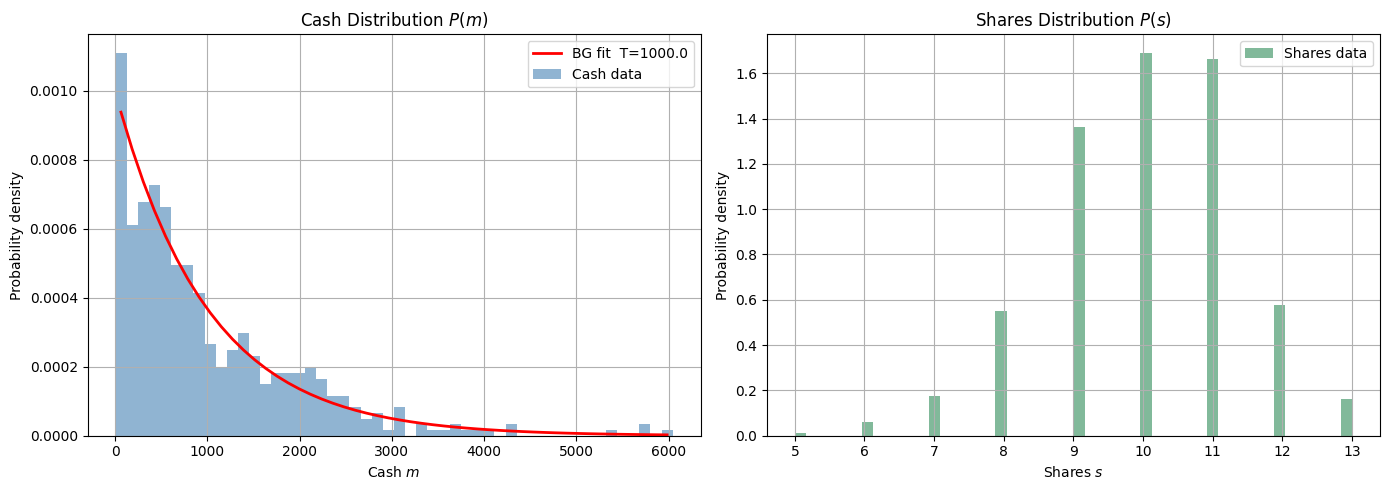

Mean cash   : 1000.00   (T = M/N = 1000.00)
Mean shares : 10.0000  (expected 10.0000)


In [6]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# ── Cash distribution ────────────────────────────────────────────────────────
T_cash = np.mean(cash)
m_hist, m_bins = np.histogram(cash, bins=50, density=True)
m_centers = 0.5 * (m_bins[1:] + m_bins[:-1])
bg_cash = (1 / T_cash) * np.exp(-m_centers / T_cash)

axs[0].bar(m_centers, m_hist, width=np.diff(m_bins), alpha=0.6, color='steelblue', label='Cash data')
axs[0].plot(m_centers, bg_cash, 'r-', lw=2, label=f'BG fit  T={T_cash:.1f}')
axs[0].set_title("Cash Distribution $P(m)$")
axs[0].set_xlabel("Cash $m$")
axs[0].set_ylabel("Probability density")
axs[0].legend()
axs[0].grid(True)

# ── Shares distribution ──────────────────────────────────────────────────────
s_hist, s_bins = np.histogram(shares, bins=50, density=True)
s_centers = 0.5 * (s_bins[1:] + s_bins[:-1])

axs[1].bar(s_centers, s_hist, width=np.diff(s_bins), alpha=0.6, color='seagreen', label='Shares data')
axs[1].set_title("Shares Distribution $P(s)$")
axs[1].set_xlabel("Shares $s$")
axs[1].set_ylabel("Probability density")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

print(f"Mean cash   : {np.mean(cash):.2f}   (T = M/N = {M/N:.2f})")
print(f"Mean shares : {np.mean(shares):.4f}  (expected {S_total/N:.4f})")

## Effect of Price-Impact Parameter $\lambda$

We vary $\lambda$ (the sensitivity of the price to trades) and observe how the **wealth inequality** (Gini coefficient) changes. A larger $\lambda$ means stronger price fluctuations, which is expected to broaden the wealth distribution and increase inequality.

λ=0.001  →  Gini=0.2284,  final price=3718.85
λ=0.005  →  Gini=0.1469,  final price=3641.57
λ=0.010  →  Gini=0.1086,  final price=5514.69
λ=0.020  →  Gini=0.0666,  final price=9183.56
λ=0.050  →  Gini=0.0898,  final price=7747.85


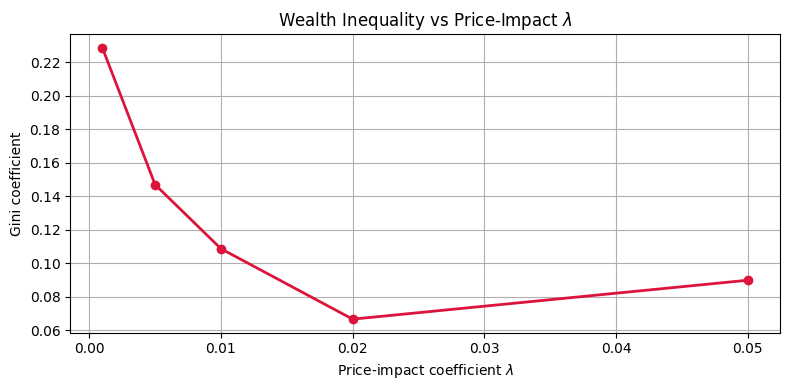

In [7]:
def gini(arr):
    """Gini coefficient of a 1-D array."""
    arr = np.sort(arr)
    n = len(arr)
    return (2 * np.dot(np.arange(1, n + 1), arr) - (n + 1) * arr.sum()) / (n * arr.sum())

lambdas  = [0.001, 0.005, 0.01, 0.02, 0.05]
gini_vals = []
final_prices = []

for lam_i in lambdas:
    c, s, pf, _, _ = simulate_stock_market(
        N=N, M=M, S_total=S_total, p0=p0, lam=lam_i, steps=steps, q_stock=0.5
    )
    w = c + pf * s
    gini_vals.append(gini(w))
    final_prices.append(pf)
    print(f"λ={lam_i:.3f}  →  Gini={gini_vals[-1]:.4f},  final price={pf:.2f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(lambdas, gini_vals, 'o-', color='crimson', lw=2)
ax.set_title("Wealth Inequality vs Price-Impact $\\lambda$")
ax.set_xlabel("Price-impact coefficient $\\lambda$")
ax.set_ylabel("Gini coefficient")
ax.grid(True)
plt.tight_layout()
plt.show()

## Effect of Stock-Trade Fraction $q_s$

We sweep the probability $q_s$ of choosing a stock trade over a cash trade. At $q_s = 0$ we recover the pure money model (BG); as $q_s \to 1$ trading is dominated by stock exchanges and price volatility dominates.

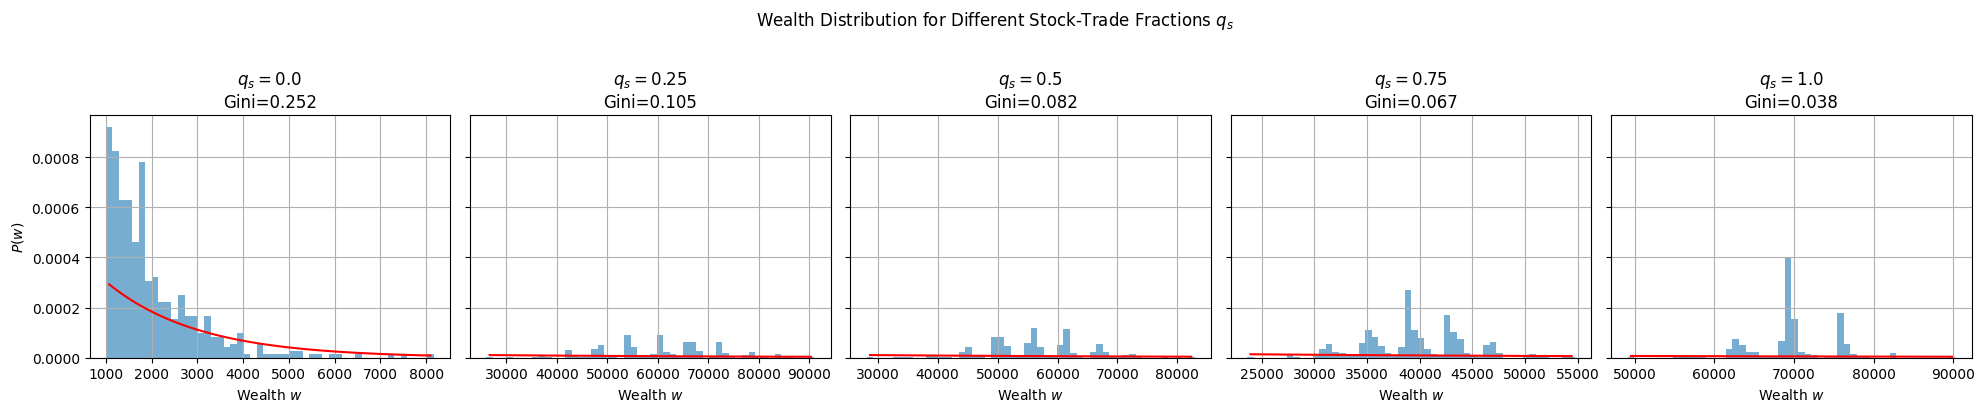

In [8]:
q_stock_vals = [0.0, 0.25, 0.5, 0.75, 1.0]
gini_qs = []

fig, axs = plt.subplots(1, len(q_stock_vals), figsize=(20, 4), sharey=True)

for idx, qs in enumerate(q_stock_vals):
    c, s, pf, _, _ = simulate_stock_market(
        N=N, M=M, S_total=S_total, p0=p0, lam=lam, steps=steps, q_stock=qs
    )
    w = c + pf * s
    gini_qs.append(gini(w))

    w_hist, w_bins = np.histogram(w, bins=50, density=True)
    w_centers = 0.5 * (w_bins[1:] + w_bins[:-1])
    T_w = np.mean(w)
    bg = (1 / T_w) * np.exp(-w_centers / T_w)

    axs[idx].bar(w_centers, w_hist, width=np.diff(w_bins), alpha=0.6)
    axs[idx].plot(w_centers, bg, 'r-', lw=1.5)
    axs[idx].set_title(f"$q_s={qs}$\nGini={gini_qs[-1]:.3f}")
    axs[idx].set_xlabel("Wealth $w$")
    axs[idx].grid(True)

axs[0].set_ylabel("$P(w)$")
plt.suptitle("Wealth Distribution for Different Stock-Trade Fractions $q_s$", y=1.02)
plt.tight_layout()
plt.show()

## Summary

| Observation | Expectation |
|---|---|
| Cash distribution $P(m)$ | Should remain close to BG (exponential), since cash trades conserve $M$ |
| Wealth distribution $P(w)$ | Expected to develop heavier tails than BG due to price fluctuations |
| Gini coefficient vs $\lambda$ | Should increase with $\lambda$ — stronger price impact → more inequality |
| Gini coefficient vs $q_s$ | Should increase with $q_s$ — more stock trading → more wealth concentration |

The key result is that **price fluctuations break strict conservation of total wealth**, lifting the equilibrium away from a pure Boltzmann-Gibbs distribution and potentially generating **Pareto tails** — consistent with empirically observed wealth distributions in real economies.